In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df = pd.read_csv("run_results.csv")

In [4]:
df.describe()

,d_model,model_depth,head_dimension,n_heads,d_ffn,vocab_size,n_params_embedding,n_params_encoder,n_params_decoder,n_params_mha,...,embedding_matrix_lr,attention_weight_matrix_lr,attention_bias_lr,w_ffn_in_lr,w_ffn_out_lr,bias_lr,unembedding_matrix_lr,final_loss,best_loss,training_wall_time
count,101.0,101.0,101.0,101.0,101.0,101.0,101.0,101.0,101.0,101.0,...,101.000000,101.000000,101.000000,101.000000,101.000000,101.000000,101.000000,101.000000,101.000000,101.000000
mean,128.0,24.0,128.0,1.0,512.0,32128.0,4112384.0,4112384.0,4112384.0,16384.0,...,0.053709,0.000420,0.053709,0.000420,0.000105,0.053709,0.000420,18.593794,8.126697,13580.498837
std,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.076873,0.000601,0.076873,0.000601,0.000150,0.076873,0.000601,52.360027,36.321697,1340.504767
min,128.0,24.0,128.0,1.0,512.0,32128.0,4112384.0,4112384.0,4112384.0,16384.0,...,0.000977,0.000008,0.000977,0.000008,0.000002,0.000977,0.000008,3.830315,3.830315,486.828972
25%,128.0,24.0,128.0,1.0,512.0,32128.0,4112384.0,4112384.0,4112384.0,16384.0,...,0.003349,0.000026,0.003349,0.000026,0.000007,0.003349,0.000026,3.864062,3.864062,13497.874735
50%,128.0,24.0,128.0,1.0,512.0,32128.0,4112384.0,4112384.0,4112384.0,16384.0,...,0.011482,0.000090,0.011482,0.000090,0.000022,0.011482,0.000090,3.944498,3.944498,13846.235856
75%,128.0,24.0,128.0,1.0,512.0,32128.0,4112384.0,4112384.0,4112384.0,16384.0,...,0.072908,0.000570,0.072908,0.000570,0.000142,0.072908,0.000570,7.162799,4.675984,13863.699151
max,128.0,24.0,128.0,1.0,512.0,32128.0,4112384.0,4112384.0,4112384.0,16384.0,...,0.250000,0.001953,0.250000,0.001953,0.000488,0.250000,0.001953,369.361493,369.361493,13982.920307


In [5]:
print(df.columns)

Index(['d_model', 'model_depth', 'head_dimension', 'n_heads', 'd_ffn',
       'vocab_size', 'n_params_embedding', 'n_params_encoder',
       'n_params_decoder', 'n_params_mha', 'n_params_rms_norm', 'n_params_ffn',
       'n_params_transformer_block', 'n_parameters', 'base_lr', 'init_stddev',
       'absolute_init_stddev', 'max_lr', 'lr_schedule_name', 'optim_name',
       'optim_beta1', 'optim_beta2', 'optim_eps', 'weight_decay',
       'n_training_tokens', 'tokens_per_global_batch', 'batch_size',
       'sequence_len', 'n_pretrain_steps', 'n_warmup_steps',
       'embedding_matrix_lr', 'attention_weight_matrix_lr',
       'attention_bias_lr', 'w_ffn_in_lr', 'w_ffn_out_lr', 'bias_lr',
       'unembedding_matrix_lr', 'run_id', 'run_folder_path',
       'run_losses_df_path', 'final_loss', 'best_loss', 'training_wall_time'],
      dtype='object')


In [6]:
print(df['n_pretrain_steps'].unique())
print(df['n_parameters'].unique())

[89208.]
[11766784]


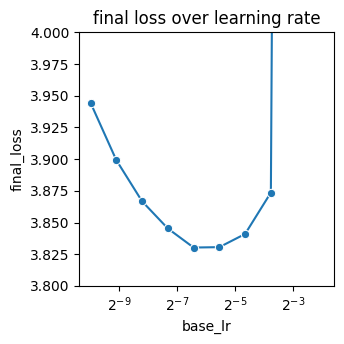

In [7]:
df_min_final_losses = df.groupby('base_lr')['final_loss'].min().reset_index()
fig, ax = plt.subplots(1, 1, figsize=(3.54, 3.54))

# final loss
sns.lineplot(df_min_final_losses,
    x="base_lr",
    y="final_loss",
    ax=ax,
    marker='o',
    )



ax.set_ylim(3.8, 4)

ax.set_xscale("log", base=2)
ax.set_title("final loss over learning rate")

plt.tight_layout()
plt.show()

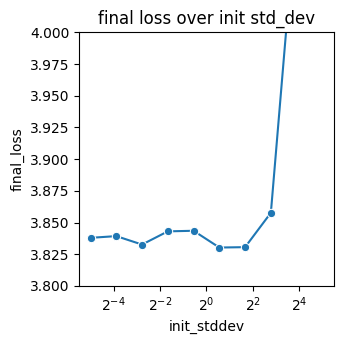

In [8]:
df_min_final_losses = df.groupby('init_stddev')['final_loss'].min().reset_index()
fig, ax = plt.subplots(1, 1, figsize=(3.54, 3.54))

# final loss
sns.lineplot(df_min_final_losses,
    x="init_stddev",
    y="final_loss",
    ax=ax,
    marker='o',
    )



ax.set_ylim(3.8, 4)
ax.set_xscale("log", base=2)

ax.set_title("final loss over init std_dev")

plt.tight_layout()
plt.show()